In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [4]:
# Load the dataset
df = pd.read_csv("mlb_salaries.csv")

# Display basic info
print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df.describe())


Shape: (28293, 12)
    playerid    player_name  weight  height bats throws  season league teamid  \
0  aardsda01  David Aardsma     215      75    R      R    2004     NL    SFN   
1  aardsda01  David Aardsma     215      75    R      R    2007     AL    CHA   
2  aardsda01  David Aardsma     215      75    R      R    2008     AL    BOS   
3  aardsda01  David Aardsma     215      75    R      R    2009     AL    SEA   
4  aardsda01  David Aardsma     215      75    R      R    2012     AL    NYA   

                   team             franchise  salary  
0  San Francisco Giants  San Francisco Giants  300000  
1     Chicago White Sox     Chicago White Sox  387500  
2        Boston Red Sox        Boston Red Sox  403250  
3      Seattle Mariners      Seattle Mariners  419000  
4      New York Yankees      New York Yankees  500000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28293 entries, 0 to 28292
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ---

In [5]:
print("Columns in df:", df.columns.tolist())


Columns in df: ['playerid', 'player_name', 'weight', 'height', 'bats', 'throws', 'season', 'league', 'teamid', 'team', 'franchise', 'salary']


In [6]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Drop rows with missing target ('salary')
df = df.dropna(subset=["salary"])

# Drop other rows with any missing values
df = df.dropna()

# Confirm cleanup
print("Missing values after cleanup:\n", df.isnull().sum())


Missing values:
 playerid       0
player_name    0
weight         0
height         0
bats           0
throws         0
season         0
league         0
teamid         0
team           0
franchise      0
salary         0
dtype: int64
Missing values after cleanup:
 playerid       0
player_name    0
weight         0
height         0
bats           0
throws         0
season         0
league         0
teamid         0
team           0
franchise      0
salary         0
dtype: int64


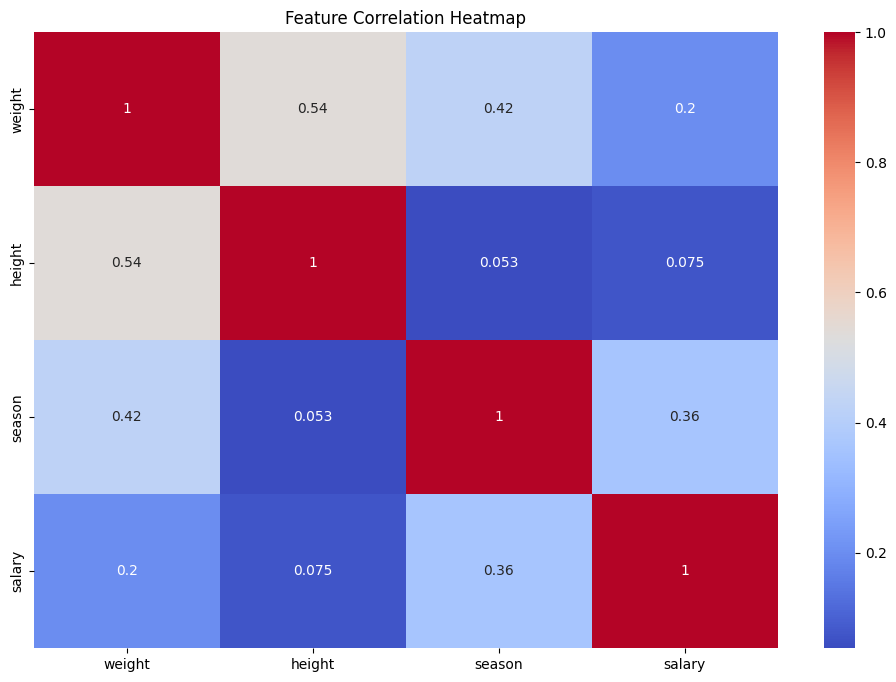

In [7]:
# Only select numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Now plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


In [14]:
columns_to_drop = ['playerid', 'player_name', 'teamid', 'team', 'franchise']

# Drop only if columns are present
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])


In [16]:
# Features and target
X = df.drop('salary', axis=1)
y = df['salary']


In [15]:
# One-hot encode valid categorical columns
df = pd.get_dummies(df, columns=['bats', 'throws', 'league'], drop_first=True)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

In [20]:
import numpy as np

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


RMSE: 3143666.212238072
